In [97]:
import yaml
from pymatgen.core import Structure, Lattice
import numpy as np

# خواندن فایل band (1).yaml
with open('band (1).yaml', 'r', encoding='utf-8') as f:
    data = yaml.safe_load(f)

# استخراج شبکه (lattice)
lattice_vectors = data['lattice']
lattice = Lattice(lattice_vectors)

# استخراج اطلاعات اتم‌ها
species = []
coords = []

for point in data['points']:
    species.append(point['symbol'])
    coords.append(point['coordinates'])

# ساخت ساختار pymatgen
structure = Structure(lattice, species, coords)

print(structure)

Full Formula (Sn2 W4 N2)
Reduced Formula: SnW2N
abc   :   3.273907   3.273907  12.973070
angles:  90.000000  90.000000 120.000000
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  W     0.666667  0.333333  0.577049
  1  W     0.666667  0.333333  0.922951
  2  W     0.333333  0.666667  0.077049
  3  W     0.333333  0.666667  0.422951
  4  Sn    0.333333  0.666667  0.75
  5  Sn    0.666667  0.333333  0.25
  6  N     0         0         0.5
  7  N     0         0         0


In [98]:
# Store structure in x
x = structure

# Extract all phonon bands
phonon_data = data['phonon']
y = []

for q_point in phonon_data:
    # Extract frequencies at each q-point
    frequencies = [band['frequency'] for band in q_point['band']]
    y.append(frequencies)

# Convert to numpy array
y = np.array(y)

print(f"Shape: {y.shape}")

Shape: (357, 24)


In [ ]:
import os
from glob import glob
from tqdm import tqdm

# تعداد فایل‌هایی که می‌خواهید پردازش شوند (None برای همه)
num_files_to_process = None  # می‌توانید این عدد را تغییر دهید یا None بگذارید

# پیدا کردن تمام فایل‌های yaml در پوشه band
band_folder = 'BigBand'
yaml_files = sorted(glob(os.path.join(band_folder, '*.yaml')))

if num_files_to_process is not None:
    yaml_files = yaml_files[:num_files_to_process]
print(f"Processing {len(yaml_files)} files")

# لیست‌های برای ذخیره داده‌ها
X = []  # ساختارها
Y = []  # باندهای فونونی

# پردازش هر فایل
for yaml_file in tqdm(yaml_files, desc="در حال پردازش فایل‌ها"):
    try:
        # خواندن فایل yaml
        with open(yaml_file, 'r', encoding='utf-8') as f:
            data = yaml.safe_load(f)
        
        # استخراج ساختار
        lattice_vectors = data['lattice']
        lattice = Lattice(lattice_vectors)
        
        species = []
        coords = []
        for point in data['points']:
            species.append(point['symbol'])
            coords.append(point['coordinates'])
        
        structure = Structure(lattice, species, coords)
        
        # استخراج باندهای فونونی
        phonon_data = data['phonon']
        frequencies_list = []
        
        for q_point in phonon_data:
            frequencies = [band['frequency'] for band in q_point['band']]
            frequencies_list.append(frequencies)
        
        frequencies_array = np.array(frequencies_list)
        
        # اضافه کردن به لیست‌ها
        X.append(structure)
        Y.append(frequencies_array)
        
    except Exception as e:
        print(f"خطا در پردازش {yaml_file}: {str(e)}")

print(f"\n{'='*50}")
print(f"تعداد ساختارهای پردازش شده: {len(X)}")
print(f"تعداد داده‌های باند: {len(Y)}")
print(f"Processed: {len(X)} structures")


Processing 1103 files


در حال پردازش فایل‌ها:  91%|█████████▏| 1007/1103 [1:35:24<05:46,  3.61s/it] 

In [ ]:
import torch


torch.save({'X': X, 'Y': Y}, 'BIGdataset_structures.pt')
print("Saved")

Saved


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv, global_add_pool
from pymatgen.core import Structure
from scipy.spatial.distance import cdist
from matbench.bench import MatbenchBenchmark
from sklearn.metrics import mean_absolute_error
import math
np.math = math

class CustomMessagePassing(nn.Module):
    """
    Custom Message Passing layer with Attention:
    message = attention_weight * (neighbor_node_features * edge_features)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Attention mechanism
        # Compute attention score from: target node + neighbor node + edge
        self.attention_mlp = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.LeakyReLU(0.2)
        )
        
        # MLP for combining messages
        self.message_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )
        
    def forward(self, x, edge_index, edge_attr):
        # edge_index: [2, num_edges]
        # edge_index[0]: source nodes (neighbors)
        # edge_index[1]: target nodes (destinations)
        
        source_nodes = edge_index[0]
        target_nodes = edge_index[1]
        
        # Neighbor and target node features
        neighbor_features = x[source_nodes]  # [num_edges, hidden_dim]
        target_features = x[target_nodes]    # [num_edges, hidden_dim]
        
        # ============ Compute Attention Scores ============
        # Combine: target node + neighbor node + edge
        attention_input = torch.cat([target_features, neighbor_features, edge_attr], dim=1)
        attention_scores = self.attention_mlp(attention_input)  # [num_edges, 1]
        
        # ============ Fast Softmax with scatter_softmax ============
        from torch_geometric.utils import softmax
        attention_weights = softmax(attention_scores, target_nodes, num_nodes=x.size(0))
        
        # ============ Multiply neighbor features by edge features ============
        messages = neighbor_features * edge_attr  # [num_edges, hidden_dim]
        
        # ============ Apply Attention Weights ============
        weighted_messages = messages * attention_weights  # [num_edges, hidden_dim]
        
        # ============ Aggregate Messages ============
        num_nodes = x.size(0)
        aggregated = torch.zeros(num_nodes, self.hidden_dim, device=x.device)
        aggregated.index_add_(0, target_nodes, weighted_messages)
        
        # Apply MLP on aggregated messages
        output = self.message_mlp(aggregated)
        
        return output

class DualGraphGNN(nn.Module):
    """
    Dual Graph GNN: Uses both bond graph and atom graph
    """
    def __init__(self, n_bond_features=6, n_atom_features=76, edge_dim=1):
        super().__init__()
        hidden = 32
        
        # ============ Bond Graph Branch ============
        self.bond_embedding = nn.Sequential(
            nn.Linear(n_bond_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.SiLU(),
            nn.Dropout(0.1),
        )
        
        self.bond_edge_embedding = nn.Sequential(
            nn.Linear(edge_dim, hidden),
            nn.SiLU(),
        )
        
        self.bond_message_layers = nn.ModuleList([
            CustomMessagePassing(hidden)
            for _ in range(4)
        ])
        
        self.bond_layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden)
            for _ in range(4)
        ])
        
        self.bond_attention = nn.Sequential(
            nn.Linear(hidden, hidden // 4),
            nn.SiLU(),
            nn.Linear(hidden // 4, 1),
            nn.Sigmoid()
        )
        
        # ============ Atom Graph Branch ============
        self.atom_embedding = nn.Sequential(
            nn.Linear(n_atom_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.SiLU(),
            nn.Dropout(0.1),
        )
        
        self.atom_edge_embedding = nn.Sequential(
            nn.Linear(edge_dim, hidden),
            nn.SiLU(),
        )
        
        self.atom_message_layers = nn.ModuleList([
            CustomMessagePassing(hidden)
            for _ in range(2)
        ])
        
        self.atom_layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden)
            for _ in range(2)
        ])
        
        self.atom_attention = nn.Sequential(
            nn.Linear(hidden, hidden // 4),
            nn.SiLU(),
            nn.Linear(hidden // 4, 1),
            nn.Sigmoid()
        )
        
        # ============ Pooling ============
        from torch_geometric.nn import Set2Set, global_mean_pool, global_max_pool
        self.set2set_pool = Set2Set(hidden, processing_steps=1)
        self.mean_pool = global_mean_pool
        self.max_pool = global_max_pool
        
        # ============ Global Features ============
        self.global_mlp = nn.Sequential(
            nn.Linear(3, hidden // 4),
            nn.SiLU(),
        )
        
        # ============ Final Prediction ============
        # Bond graph: 2*hidden (Set2Set) + hidden (mean) + hidden (max) = 4*hidden
        # Atom graph: 2*hidden (Set2Set) + hidden (mean) + hidden (max) = 4*hidden
        # Global: hidden//4
        final_input = 8 * hidden + hidden // 4
        t = 1024
        self.final_mlp = nn.Sequential(
            nn.Linear(final_input, t),
            nn.LayerNorm(t),
            nn.SiLU(),
            nn.Dropout(0.5),
            nn.Linear(t, t//2),
            nn.LayerNorm(t//2),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(t//2, t//4),
            nn.LayerNorm(t//4),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(t//4, 13)  # خروجی: 9 مقدار (4 left + min + 4 right)
        )
    
    def forward(self, bond_data, atom_data):
        # ============ Bond Graph Forward ============
        x_bond = self.bond_embedding(bond_data.x)
        edge_features_bond = self.bond_edge_embedding(bond_data.edge_attr)
        
        for i, (message_layer, layer_norm) in enumerate(zip(self.bond_message_layers, self.bond_layer_norms)):
            x_residual = x_bond
            x_bond = message_layer(x_bond, bond_data.edge_index, edge_features_bond)
            x_bond = layer_norm(x_bond)
            if i > 0:
                x_bond = x_bond + 0.3 * x_residual
            x_bond = F.silu(x_bond)
        
        attention_weights_bond = self.bond_attention(x_bond)
        x_bond_weighted = x_bond * attention_weights_bond
        
        bond_set2set = self.set2set_pool(x_bond_weighted, bond_data.batch)
        bond_mean = self.mean_pool(x_bond, bond_data.batch)
        bond_max = self.max_pool(x_bond, bond_data.batch)
        
        # ============ Atom Graph Forward ============
        x_atom = self.atom_embedding(atom_data.x)
        edge_features_atom = self.atom_edge_embedding(atom_data.edge_attr)
        
        for i, (message_layer, layer_norm) in enumerate(zip(self.atom_message_layers, self.atom_layer_norms)):
            x_residual = x_atom
            x_atom = message_layer(x_atom, atom_data.edge_index, edge_features_atom)
            x_atom = layer_norm(x_atom)
            if i > 0:
                x_atom = x_atom + 0.3 * x_residual
            x_atom = F.silu(x_atom)
        
        attention_weights_atom = self.atom_attention(x_atom)
        x_atom_weighted = x_atom * attention_weights_atom
        
        atom_set2set = self.set2set_pool(x_atom_weighted, atom_data.batch)
        atom_mean = self.mean_pool(x_atom, atom_data.batch)
        atom_max = self.max_pool(x_atom, atom_data.batch)
        
        # ============ Global Features ============
        global_features = self.global_mlp(bond_data.u)
        
        # ============ Combine & Predict ============
        combined = torch.cat([
            bond_set2set, bond_mean, bond_max,
            atom_set2set, atom_mean, atom_max,
            global_features
        ], dim=1)
        
        out = self.final_mlp(combined)
        
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DualGraphGNN(n_bond_features=81, n_atom_features=76, edge_dim=1).to(device)

print(f"✅ Dual Graph GNN Model: {sum(p.numel() for p in model.parameters()):,} params")


✅ Dual Graph GNN Model: 969,205 params


In [86]:
def train_epoch_dual(model, bond_loader, atom_loader, optimizer, device):
    """Train with dual graphs"""
    model.train()
    total_loss = 0
    n_samples = 0
    
    for bond_data, atom_data in zip(bond_loader, atom_loader):
        bond_data = bond_data.to(device)
        atom_data = atom_data.to(device)
        
        optimizer.zero_grad()
        
        pred = model(bond_data, atom_data)
        target = bond_data.y.view(bond_data.num_graphs, 357, 24)
        loss = F.mse_loss(pred, target)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * bond_data.num_graphs
        n_samples += bond_data.num_graphs
    
    return total_loss / n_samples

def evaluate_dual(model, bond_loader, atom_loader, device):
    """Evaluate with dual graphs"""
    model.eval()
    total_loss = 0
    n_samples = 0
    
    with torch.no_grad():
        for bond_data, atom_data in zip(bond_loader, atom_loader):
            bond_data = bond_data.to(device)
            atom_data = atom_data.to(device)
            
            pred = model(bond_data, atom_data)
            target = bond_data.y.view(bond_data.num_graphs, 357, 24)
            loss = F.mse_loss(pred, target)
            
            total_loss += loss.item() * bond_data.num_graphs
            n_samples += bond_data.num_graphs
    
    return total_loss / n_samples



In [87]:
# Load periodic table (76 features per element)
df_ptable = pd.read_csv('ptable.csv')
df_ptable.fillna(0, inplace=True)
df_ptable.drop(['electronic_configuration', 'name', 'block', 'lattice_structure', 'is_radioactive'], 
               axis=1, inplace=True, errors='ignore')

n_features = len(df_ptable.columns) - 1  # Exclude 'symbol' column
print(f"✅ Loaded ptable: {n_features} features/atom")

✅ Loaded ptable: 76 features/atom


In [88]:
from torch_geometric.data import Data
from scipy.spatial.distance import cdist
from tqdm import tqdm

data_loaded = torch.load('dataset_structures.pt')
X_structures = data_loaded['X']
Y_bands = data_loaded['Y']

def structure_to_graph_full(structure, band_data):
    """
    Convert structure to graph with full target (357 × 24)
    """
    # Create supercell
    structure = structure.copy()
    structure.make_supercell([1, 1, 1])
    
    # Extract node features
    node_features = []
    atomic_numbers = []
    
    for site in structure.sites:
        Z = site.specie.Z
        atomic_numbers.append(Z)
        features = df_ptable.iloc[Z - 1, 1:].values.astype(np.float32)
        node_features.append(features)
    
    x = torch.tensor(node_features, dtype=torch.float)
    z = torch.tensor(atomic_numbers, dtype=torch.long)
    
    # Positions
    positions = np.array([site.coords for site in structure.sites])
    pos = torch.tensor(positions, dtype=torch.float)
    
    # Edges with cutoff
    distances = cdist(positions, positions)
    edge_index = []
    edge_attr = []
    
    cutoff = 8  # Angstrom
    
    n_atoms = len(positions)
    for i in range(n_atoms):
        for j in range(n_atoms):
            if i != j and distances[i, j] <= cutoff:
                edge_index.append([i, j])
                edge_attr.append([distances[i, j]])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    # Target: 4 points left + 4 points right of minimum in lowest band
    # band_data shape: (357, 24)
    # Find the band with minimum value
    band_mins = np.min(band_data, axis=0)  # min of each band
    lowest_band_idx = np.argmin(band_mins)
    lowest_band = band_data[:, lowest_band_idx]  # (357,)
    
    # Find minimum in this band
    min_idx = np.argmin(lowest_band)
    
    # Get 4 left and 4 right points
    left_start = max(0, min_idx - 6)
    right_end = min(len(lowest_band), min_idx + 7)
    
    values = lowest_band[left_start:right_end]
    
    # Pad if needed
    if len(values) < 13:
        values = np.pad(values, (0, 13 - len(values)), mode='edge')
    
    y = torch.tensor(values, dtype=torch.float)
    
    # Global features
    u = torch.tensor([[structure.volume / n_atoms]], dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, pos=pos, z=z, u=u)




In [89]:
def structure_to_bond_graph(structure, band_data):
    """
    Convert structure to bond graph with full target (357 × 24)
    Nodes = bonds, Edges = angles between bonds
    """
    structure = structure.copy()
    structure.make_supercell([1, 1, 1])
    
    positions = np.array([site.coords for site in structure.sites])
    distances = cdist(positions, positions)
    cutoff = 8
    
    # Find all bonds
    bonds = []
    for i in range(len(positions)):
        for j in range(i + 1, len(positions)):
            if distances[i, j] <= cutoff:
                bonds.append((i, j))
    
    if len(bonds) == 0:
        # If no bonds found, create empty node
        x = torch.zeros((1, 81), dtype=torch.float)
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 1), dtype=torch.float)
        y = torch.tensor(band_data, dtype=torch.float)
        
        lattice = structure.lattice
        spacegroup_num = 1
        try:
            from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
            sga = SpacegroupAnalyzer(structure)
            spacegroup_num = sga.get_space_group_number()
        except:
            pass
        
        u = torch.tensor([[
            structure.volume / len(positions),
            spacegroup_num,
            lattice.volume
        ]], dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u)
    
    # Create node features for each bond
    node_features = []
    for (i, j) in bonds:
        Z_i = structure.sites[i].specie.Z
        Z_j = structure.sites[j].specie.Z
        
        features_i = df_ptable.iloc[Z_i - 1, 1:].values.astype(np.float32)
        features_j = df_ptable.iloc[Z_j - 1, 1:].values.astype(np.float32)
        
        bond_feature = np.zeros(1)
        
        bond_distance = distances[i, j]
        coord_i = np.sum(distances[i, :] <= cutoff) - 1
        coord_j = np.sum(distances[j, :] <= cutoff) - 1
        
        lattice = structure.lattice
        spacegroup_num = 1
        lattice_type = 0
        
        try:
            from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
            sga = SpacegroupAnalyzer(structure)
            spacegroup_num = sga.get_space_group_number()
            crystal_system = sga.get_crystal_system()
            
            system_map = {
                'cubic': 0, 'tetragonal': 1, 'orthorhombic': 2,
                'hexagonal': 3, 'trigonal': 4, 'monoclinic': 5, 'triclinic': 6
            }
            lattice_type = system_map.get(crystal_system, 0)
        except:
            pass
        
        bond_feature = np.concatenate([
            bond_feature, 
            [bond_distance, (coord_i + coord_j) / 2, spacegroup_num / 230.0, lattice_type / 6.0, lattice.volume]
        ])
        node_features.append(bond_feature)
    
    x = torch.tensor(node_features, dtype=torch.float)
    
    # Create edges between bonds (angles)
    edge_index = []
    edge_attr = []
    
    for bond_idx1, (i1, j1) in enumerate(bonds):
        for bond_idx2, (i2, j2) in enumerate(bonds):
            if bond_idx1 != bond_idx2:
                shared_atom = None
                if i1 in (i2, j2):
                    shared_atom = i1
                    other1, other2 = j1, (j2 if i1 == i2 else i2)
                elif j1 in (i2, j2):
                    shared_atom = j1
                    other1, other2 = i1, (j2 if j1 == i2 else i2)
                
                if shared_atom is not None:
                    vec1 = positions[other1] - positions[shared_atom]
                    vec2 = positions[other2] - positions[shared_atom]
                    
                    cos_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
                    cos_angle = np.clip(cos_angle, -1, 1)
                    angle = np.arccos(cos_angle)
                    
                    edge_index.append([bond_idx1, bond_idx2])
                    edge_attr.append([angle])
    
    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 1), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    # Target: 4 points left + 4 points right of minimum in lowest band
    # band_data shape: (357, 24)
    # Find the band with minimum value
    band_mins = np.min(band_data, axis=0)  # min of each band
    lowest_band_idx = np.argmin(band_mins)
    lowest_band = band_data[:, lowest_band_idx]  # (357,)
    
    # Find minimum in this band
    min_idx = np.argmin(lowest_band)
    
    # Get 4 left and 4 right points
    left_start = max(0, min_idx - 6)
    right_end = min(len(lowest_band), min_idx + 7)
    
    values = lowest_band[left_start:right_end]
    
    # Pad if needed
    if len(values) < 13:
        values = np.pad(values, (0, 13 - len(values)), mode='edge')
    
    y = torch.tensor(values, dtype=torch.float)
    
    # Global features
    lattice = structure.lattice
    spacegroup_num = 1
    try:
        from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
        sga = SpacegroupAnalyzer(structure)
        spacegroup_num = sga.get_space_group_number()
    except:
        pass
    
    u = torch.tensor([[
        structure.volume / len(positions),
        spacegroup_num,
        lattice.volume
    ]], dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u)


In [90]:
# Convert all structures to both graph types
print("\nConverting structures to atomic graphs...")
atomic_graph_list = []
for i in tqdm(range(len(X_structures)), desc="Atomic Graphs"):
    try:
        graph = structure_to_graph_full(X_structures[i], Y_bands[i])
        atomic_graph_list.append(graph)
    except Exception as e:
        print(f"Error {i} (atomic): {str(e)}")

print("\nConverting structures to bond graphs...")
bond_graph_list = []
for i in tqdm(range(len(X_structures)), desc="Bond Graphs"):
    try:
        graph = structure_to_bond_graph(X_structures[i], Y_bands[i])
        bond_graph_list.append(graph)
    except Exception as e:
        print(f"Error {i} (bond): {str(e)}")

print(f"\n{'='*60}")
print(f"✅ Atomic graphs created: {len(atomic_graph_list)}")
print(f"✅ Bond graphs created: {len(bond_graph_list)}")
print(f"{'='*60}")

# Show sample from each graph type
if len(atomic_graph_list) > 0:
    sample_atomic = atomic_graph_list[0]
    print(f"\n📊 Sample Atomic Graph:")
    print(f"   Nodes: {sample_atomic.num_nodes} (atoms)")
    print(f"   Edges: {sample_atomic.num_edges}")
    print(f"   Node features: {sample_atomic.x.shape[1]}")
    print(f"   Edge features: {sample_atomic.edge_attr.shape[1]}")

if len(bond_graph_list) > 0:
    sample_bond = bond_graph_list[0]
    print(f"\n📊 Sample Bond Graph:")
    print(f"   Nodes: {sample_bond.num_nodes} (bonds)")
    print(f"   Edges: {sample_bond.num_edges} (angles)")
    print(f"   Node features: {sample_bond.x.shape[1]}")
    print(f"   Edge features: {sample_bond.edge_attr.shape[1]}")
    print(f"{'='*60}")

graph_list = atomic_graph_list


Converting structures to atomic graphs...


Atomic Graphs: 100%|██████████| 358/358 [00:01<00:00, 341.08it/s]



Converting structures to bond graphs...


Bond Graphs: 100%|██████████| 358/358 [00:07<00:00, 49.67it/s]


✅ Atomic graphs created: 358
✅ Bond graphs created: 358

📊 Sample Atomic Graph:
   Nodes: 8 (atoms)
   Edges: 46
   Node features: 76
   Edge features: 1

📊 Sample Bond Graph:
   Nodes: 23 (bonds)
   Edges: 228 (angles)
   Node features: 6
   Edge features: 1


In [ ]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import time

train_bond_graphs, test_bond_graphs = train_test_split(bond_graph_list, test_size=0.2, random_state=42)
train_atom_graphs, test_atom_graphs = train_test_split(atomic_graph_list, test_size=0.2, random_state=42)

# Create paired datasets (IMPORTANT: zip them together!)
train_dataset = list(zip(train_bond_graphs, train_atom_graphs))
test_dataset = list(zip(test_bond_graphs, test_atom_graphs))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check actual number of features in bond graph
sample_bond = train_bond_graphs[0]
n_bond_features = sample_bond.x.shape[1]
print(f"📊 Detected bond graph features: {n_bond_features}")
print(f"📊 Atom graph features: 76")

# Recreate model with correct feature sizes
model = DualGraphGNN(n_bond_features=n_bond_features, n_atom_features=76, edge_dim=1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler with ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.8, patience=3, verbose=True, min_lr=1e-6
)

# ============ MSE Loss for Regression ============
# حالا که target مینیمم فرکانس است (regression)، از MSE استفاده می‌کنیم
train_targets = [graph.y[0].item() for graph in train_bond_graphs]
min_target = min(train_targets)
max_target = max(train_targets)
mean_target = sum(train_targets) / len(train_targets)

print(f"📊 Train dataset target statistics:")
print(f"   Min frequency: {min_target:.4f} THz")
print(f"   Max frequency: {max_target:.4f} THz")
print(f"   Mean frequency: {mean_target:.4f} THz")
print(f"   Negative samples: {sum([1 for t in train_targets if t < 0])}")
print(f"   Positive samples: {sum([1 for t in train_targets if t >= 0])}")

# MSE Loss برای regression
criterion = F.mse_loss
criterion_name = 'MSE'

print(f"🚀 Training Dual Graph GNN Model")
print(f"{'='*60}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Criterion: {criterion_name}")
print(f"{'='*60}\n")

best_loss = float('inf')
patience = 0
max_patience = 100
n_epochs = 500

for epoch in range(n_epochs):
    # Training
    model.train()
    total_loss = 0
    
    for bond_data, atom_data in train_loader:
        bond_data = bond_data.to(device)
        atom_data = atom_data.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass - مدل 10 تا از کمترین فرکانس‌ها رو پیش‌بینی می‌کنه
        pred = model(bond_data, atom_data)  # [batch_size, 10]
        
        # Target
        target = bond_data.y.view(bond_data.num_graphs, 13)
        
        # Loss - MSE برای regression
        loss = criterion(pred, target)
        
        # Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * bond_data.num_graphs
    
    train_loss = total_loss / len(train_dataset)
    
    # Evaluation every 5 epochs
    if epoch % 5 == 0 or epoch == n_epochs - 1:
        model.eval()
        test_loss = 0
        
        with torch.no_grad():
            for bond_data, atom_data in test_loader:
                bond_data = bond_data.to(device)
                atom_data = atom_data.to(device)
                
                pred = model(bond_data, atom_data)
                target = bond_data.y.view(bond_data.num_graphs, 13)
                loss = criterion(pred, target)
                
                test_loss += loss.item() * bond_data.num_graphs
        
        test_loss = test_loss / len(test_dataset)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Update scheduler based on test loss
        scheduler.step(test_loss)
        
        # ذخیره بهترین مدل
        if test_loss < best_loss:
            best_loss = test_loss
            patience = 0
            torch.save(model.state_dict(), 'best_dual_phonon_model.pt')
            print(f"✓ Epoch {epoch:3d} | Train: {train_loss:.6f} | Test: {test_loss:.6f} ⭐ | LR: {current_lr:.6f} | {criterion_name}")
        else:
            patience += 5
            if epoch % 20 == 0:
                print(f"  Epoch {epoch:3d} | Train: {train_loss:.6f} | Test: {test_loss:.6f} | LR: {current_lr:.6f} | {criterion_name}")
        
        if patience >= max_patience:
            print(f"\n⚠️ Early stop at epoch {epoch}")
            break

print(f"\n{'='*60}")
print(f"✅ Training completed!")
print(f"Best Test Loss ({criterion_name}): {best_loss:.6f}")
print(f"{'='*60}")

# Load best model
model.load_state_dict(torch.load('best_dual_phonon_model.pt'))
print(f"✅ Loaded best model")

📊 Detected bond graph features: 6
📊 Atom graph features: 76
📊 Train dataset target statistics:
   Min frequency: -3.7903 THz
   Max frequency: 0.9482 THz
   Mean frequency: -0.4112 THz
   Negative samples: 96
   Positive samples: 11
🚀 Training Dual Graph GNN Model
Train samples: 107
Test samples: 251
Batch size: 32
Batches per epoch: 4
Criterion: MSE



KeyError: 'batch'

In [92]:
# انتخاب یک نمونه از دیتای تست
model.eval()
sample_idx = 1
sample_bond_graph = test_bond_graphs[sample_idx]
sample_atom_graph = test_atom_graphs[sample_idx]

# پیش‌بینی با دو گراف
with torch.no_grad():
    sample_bond_graph = sample_bond_graph.to(device)
    sample_atom_graph = sample_atom_graph.to(device)
    sample_bond_graph.batch = torch.zeros(sample_bond_graph.num_nodes, dtype=torch.long, device=device)
    sample_atom_graph.batch = torch.zeros(sample_atom_graph.num_nodes, dtype=torch.long, device=device)
    
    prediction = model(sample_bond_graph, sample_atom_graph).cpu().numpy()[0]  # top-10 minimum frequencies
    target = sample_bond_graph.y.cpu().numpy()  # actual top-10 minimum frequencies

print(f"📊 Top-10 Minimum Frequencies Prediction:")
print(f"\n   Predicted (THz):")
for i, p in enumerate(prediction, 1):
    print(f"      {i:2d}. {p:8.4f}")
print(f"\n   Actual (THz):")
for i, t in enumerate(target, 1):
    print(f"      {i:2d}. {t:8.4f}")

mae_sample = np.mean(np.abs(prediction - target))
print(f"\n   MAE: {mae_sample:.4f} THz")

# Check stability (based on minimum value)
pred_stable = "Stable (no negative)" if prediction[0] >= 0 else "Unstable (has negative)"
actual_stable = "Stable (no negative)" if target[0] >= 0 else "Unstable (has negative)"
print(f"\n   Predicted stability: {pred_stable}")
print(f"   Actual stability:    {actual_stable}")
print(f"   Stability correct: {'✓' if (prediction[0] >= 0) == (target[0] >= 0) else '✗'}")

📊 Top-10 Minimum Frequencies Prediction:

   Predicted (THz):
       1.   0.0469
       2.   0.1466
       3.   0.2411
       4.   0.3627
       5.   0.4585
       6.   0.5720
       7.   0.6826
       8.   0.6804
       9.   0.6887
      10.   0.6899
      11.   0.6832
      12.   0.6989
      13.   0.6934

   Actual (THz):
       1.   0.5726
       2.  -0.2504
       3.  -0.6176
       4.  -0.7920
       5.  -0.8943
       6.  -0.9489
       7.  -0.9651
       8.  -0.9475
       9.  -0.8979
      10.  -0.8172
      11.  -0.7054
      12.  -0.5632
      13.  -0.3932

   MAE: 1.2244 THz

   Predicted stability: Stable (no negative)
   Actual stability:    Stable (no negative)
   Stability correct: ✓


Evaluating: 100%|██████████| 72/72 [00:00<00:00, 137.25it/s]


Class 0 (not all negative): 58/61 correctly predicted
Class 1 (all negative): 2/11 correctly predicted


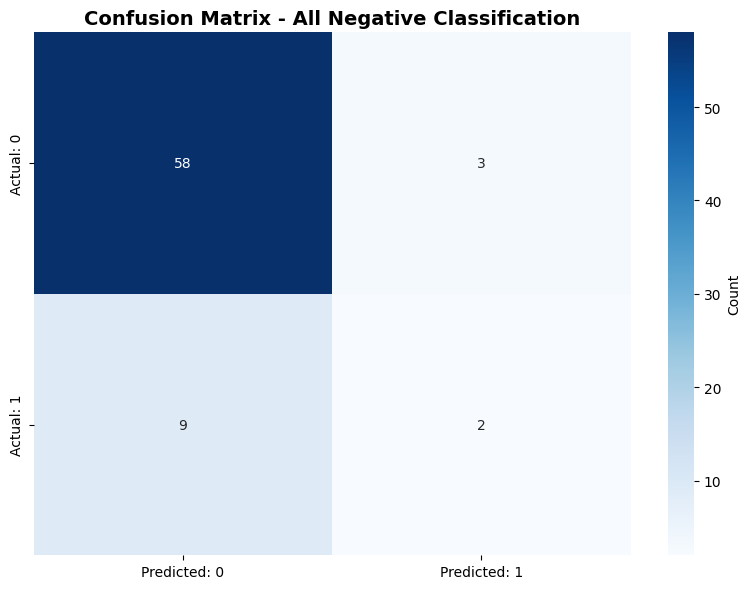

In [94]:
# محاسبه خطا برای تمام دیتای تست
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for idx in tqdm(range(len(test_bond_graphs)), desc="Evaluating"):
        sample_bond_graph = test_bond_graphs[idx].to(device)
        sample_atom_graph = test_atom_graphs[idx].to(device)
        
        sample_bond_graph.batch = torch.zeros(sample_bond_graph.num_nodes, dtype=torch.long, device=device)
        sample_atom_graph.batch = torch.zeros(sample_atom_graph.num_nodes, dtype=torch.long, device=device)
        
        prediction = model(sample_bond_graph, sample_atom_graph).cpu().numpy()[0]  # [10] top-k minimum
        target = sample_bond_graph.y.cpu().numpy()  # [10] actual top-k minimum
        
        all_predictions.append(prediction)
        all_targets.append(target)

# تبدیل به numpy arrays
all_predictions = np.array(all_predictions)  # [n_samples, 9]
all_targets = np.array(all_targets)  # [n_samples, 9]

# تبدیل به binary labels: 1 اگه همه منفی باشن، 0 اگه نه
binary_predictions = np.array([1 if np.all(pred < 0) else 0 for pred in all_predictions])
binary_targets = np.array([1 if np.all(target < 0) else 0 for target in all_targets])

# شمارش پیش‌بینی‌های درست
from sklearn.metrics import confusion_matrix
import seaborn as sns

correct_0 = sum([1 for i in range(len(binary_targets)) if binary_targets[i] == 0 and binary_predictions[i] == 0])
correct_1 = sum([1 for i in range(len(binary_targets)) if binary_targets[i] == 1 and binary_predictions[i] == 1])
total_0 = sum([1 for t in binary_targets if t == 0])
total_1 = sum([1 for t in binary_targets if t == 1])

print(f"Class 0 (not all negative): {correct_0}/{total_0} correctly predicted")
print(f"Class 1 (all negative): {correct_1}/{total_1} correctly predicted")

# Confusion matrix
cm = confusion_matrix(binary_targets, binary_predictions)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: 0', 'Predicted: 1'],
            yticklabels=['Actual: 0', 'Actual: 1'],
            ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Confusion Matrix - All Negative Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()